
# Olist E-commerce Analysis

## Customer Revenue Analysis

### Objective

The objective of this project is to analyze customer value and revenue distribution using historical customer revenue.

The analysis aims to answer the following business questions:

- How much revenue does each customer generate?
- Who are the highest-value customers?
- How concentrated is revenue among customers?
- What percentage of customers generates most of the revenue?
- What proportion of customers makes repeat purchases?

In this project, customer lifetime revenue refers to the total payment value generated by each customer during the period covered by the dataset. It is not a predictive Customer Lifetime Value (CLV) model.

## 1.Dataset Description

This project uses the Olist Brazilian E-commerce Public Dataset.

The complete dataset contains information about:

- Customers
- Orders
- Order payments
- Products
- Sellers
- Customer reviews
- Geographic locations

For this analysis, three datasets will be used:

- `olist_customers_dataset.csv`
- `olist_orders_dataset.csv`
- `olist_payments_dataset.csv`

These datasets will be combined to create an order-level analytical table and calculate customer revenue metrics.

The main customer identifier used in the analysis will be `customer_unique_id`, because `customer_id` identifies a customer within a specific order, while `customer_unique_id` can connect purchases made by the same customer.

In [8]:
 #Import libraries required for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub


In [9]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# Load required datasets
customers = pd.read_csv(
    os.path.join(path, "olist_customers_dataset.csv")
)

orders = pd.read_csv(
    os.path.join(path, "olist_orders_dataset.csv")
)

payments = pd.read_csv(
    os.path.join(path, "olist_order_payments_dataset.csv")
)

print("Datasets loaded successfully")

Datasets loaded successfully


# 2. Dataset Overview
The project uses three datasets from the Olist Brazilian E-commerce dataset:

- **customers:** customer identifiers and geographic information.
- **orders:** purchase lifecycle information including purchase, approval, delivery and estimated delivery dates.
- **payments:** payment amount, payment method and number of installments.

The purpose of this stage is to understand the structure of each dataset before performing any cleaning or transformations.

In [10]:
# Check dataset dimensions

datasets = {
    "Customers": customers,
    "Orders": orders,
    "Payments": payments
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}")


Customers
Rows: 99,441
Columns: 5

Orders
Rows: 99,441
Columns: 8

Payments
Rows: 103,886
Columns: 5


In [11]:
customers.info()
orders.info()
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281

## 3. Data Quality Assessment and Cleaning

Before creating the analytical dataset, the three tables were assessed for:

- Missing values
- Duplicate rows
- Duplicate primary keys
- Incorrect data types
- Unexpected relationships between tables

Datetime columns were converted to the appropriate data type to support time-based analysis.

### 3.1 Datetime Conversion

The order date columns were initially stored as text. They were converted to the datetime data type using `errors="coerce"` so that invalid values, if present, would be represented as missing timestamps.

In [12]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(
        orders[column],
        errors="coerce"
    )

orders[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

### 3.2 Duplicate Assessment

Duplicate rows and duplicated identifiers were checked separately.

A duplicated full row may indicate a data quality problem. However, repeated `order_id` values in the payments table are expected because one order can contain multiple payment records.

In [14]:
duplicate_rows = pd.DataFrame({
    "dataset": ["customers", "orders", "payments"],
    "duplicate_rows": [
        customers.duplicated().sum(),
        orders.duplicated().sum(),
        payments.duplicated().sum()
    ]
})

print(duplicate_rows)

     dataset  duplicate_rows
0  customers               0
1     orders               0
2   payments               0


In [15]:
key_validation = pd.DataFrame({
    "validation": [
        "Duplicated customer_id in customers",
        "Duplicated order_id in orders",
        "Duplicated payment identifier"
    ],
    "duplicates": [
        customers["customer_id"].duplicated().sum(),
        orders["order_id"].duplicated().sum(),
        payments.duplicated(
            subset=["order_id", "payment_sequential"]
        ).sum()
    ]
})



#### Duplicate Assessment Findings

- No fully duplicated rows were identified in the three datasets.
- `customer_id` is unique in the customers table.
- `order_id` is unique in the orders table.
- The combination of `order_id` and `payment_sequential` is unique in the payments table.
- Repeated `order_id` values in the payments table are expected because an order can contain multiple payment records.

In [16]:
def missing_values_summary(dataframe):
    summary = (
        dataframe
        .isna()
        .sum()
        .rename("missing_values")
        .reset_index()
        .rename(columns={"index": "column"})
    )

    summary["missing_percentage"] = (
        summary["missing_values"]
        .div(len(dataframe))
        .mul(100)
        .round(2)
    )

    return (
        summary[
            summary["missing_values"] > 0
        ]
        .sort_values(
            "missing_percentage",
            ascending=False
        )
        .reset_index(drop=True)
    )
print("Missing values — Customers")
display(missing_values_summary(customers))

print("Missing values — Orders")
display(missing_values_summary(orders))

print("Missing values — Payments")
display(missing_values_summary(payments))


Missing values — Customers


,column,missing_values,missing_percentage


Missing values — Orders


,column,missing_values,missing_percentage
0,order_delivered_customer_date,2965,2.98
1,order_delivered_carrier_date,1783,1.79
2,order_approved_at,160,0.16


Missing values — Payments


,column,missing_values,missing_percentage


#### Initial Missing Values Findings

Missing values were identified only in three order timestamp columns:

- `order_delivered_customer_date`: 2.98%
- `order_delivered_carrier_date`: 1.79%
- `order_approved_at`: 0.16%

The missing values were not removed automatically. Their relationship with `order_status` was examined to determine whether they represent incomplete order lifecycle stages or potential data quality issues.

In [17]:
orders_missing_analysis = orders.assign(
    missing_approved_date=orders["order_approved_at"].isna(),
    missing_carrier_date=orders["order_delivered_carrier_date"].isna(),
    missing_customer_date=orders["order_delivered_customer_date"].isna()
)

missing_by_status = (
    orders_missing_analysis
    .groupby("order_status", as_index=False)
    .agg(
        total_orders=("order_id", "size"),
        missing_approved_date=("missing_approved_date", "sum"),
        missing_carrier_date=("missing_carrier_date", "sum"),
        missing_customer_date=("missing_customer_date", "sum")
    )
    .sort_values("total_orders", ascending=False)
)

missing_by_status
missing_by_status["missing_approved_percentage"] = (
    missing_by_status["missing_approved_date"]
    .div(missing_by_status["total_orders"])
    .mul(100)
    .round(2)
)

missing_by_status["missing_carrier_percentage"] = (
    missing_by_status["missing_carrier_date"]
    .div(missing_by_status["total_orders"])
    .mul(100)
    .round(2)
)

missing_by_status["missing_customer_percentage"] = (
    missing_by_status["missing_customer_date"]
    .div(missing_by_status["total_orders"])
    .mul(100)
    .round(2)
)
missing_by_status



,order_status,total_orders,missing_approved_date,missing_carrier_date,missing_customer_date,missing_approved_percentage,missing_carrier_percentage,missing_customer_percentage
3,delivered,96478,14,2,8,0.01,0.0,0.01
6,shipped,1107,0,0,1107,0.00,0.0,100.00
1,canceled,625,141,550,619,22.56,88.0,99.04
7,unavailable,609,0,609,609,0.00,100.0,100.00
4,invoiced,314,0,314,314,0.00,100.0,100.00
5,processing,301,0,301,301,0.00,100.0,100.00
2,created,5,5,5,5,100.00,100.0,100.00
0,approved,2,0,2,2,0.00,100.0,100.00


### Missing Values Findings

Most missing values are related to orders that did not complete the delivery process.

Orders with statuses such as `shipped`, `canceled`, `unavailable`, `invoiced` and `processing` commonly have missing delivery dates because they did not reach the final delivery stage.

A small number of delivered orders also have missing dates, indicating minor data quality inconsistencies.

The missing values were not removed or replaced because the actual dates are unknown. The appropriate records will be selected later depending on the analysis.

### 3.4 Relationship Validation
# Before merging the datasets, the relationships between the primary and foreign keys were validated to ensurere referential integrity.


In [18]:
customer_relationship = (
    orders["customer_id"]
    .isin(customers["customer_id"])
    .all()
)

payment_relationship = (
    payments["order_id"]
    .isin(orders["order_id"])
    .all()
)

relationship_validation = pd.DataFrame({
    "Relationship": [
        "orders.customer_id → customers.customer_id",
        "payments.order_id → orders.order_id"
    ],
    "Valid": [
        customer_relationship,
        payment_relationship
    ]
})

relationship_validation

,Relationship,Valid
0,orders.customer_id → customers.customer_id,True
1,payments.order_id → orders.order_id,True


#### Relationship Validation Findings

Both foreign key relationships are valid.

- Every customer referenced in the orders table exists in the customers dataset.
- Every payment record is associated with an existing order.

This confirms that the datasets can be safely merged without generating orphan records.

### 4. Order Status Analysis

### 4.1 Delivery Metrics

Two delivery-related metrics were created to evaluate shipping performance.

- **delivery_time:** number of days between the purchase date and the actual delivery date.
- **delay_days:** difference between the actual delivery date and the estimated delivery date.

Positive values indicate late deliveries, while negative values indicate deliveries completed before the estimated date.

In [19]:
orders["delivery_time"] = (
    orders["order_delivered_customer_date"]
    -
    orders["order_purchase_timestamp"]
).dt.days

orders["delays_days"] = (
    orders["order_delivered_customer_date"]
    -
    orders["order_estimated_delivery_date"]
).dt.days


In [20]:
orders[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_time",
        "delays_days",
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,delays_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.0,-8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.0,-6.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.0,-18.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.0,-13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.0,-10.0


## 5. Exploratory Data Analysis (EDA)

### 5.1 Order Status Distribution

In [21]:

status_summary= (orders["order_status"]
    .value_counts().rename("total_orders")
    .to_frame()
    .reset_index())

total = status_summary["total_orders"].sum()
status_summary["percentage"] = (status_summary["total_orders"] / total) * 100
status_summary["percentage"] = status_summary["percentage"].round(2)




payments = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
revenue_payment = (
    payments
    .groupby("payment_type")
    .agg(
    total_revenue = ("payment_value", "sum")

    )
    .reset_index()
)
revenue_payment.sort_values(ascending=False, by="total_revenue", inplace=True)
print(revenue_payment)



  payment_type  total_revenue
1  credit_card    12542084.19
0       boleto     2869361.27
4      voucher      379436.87
2   debit_card      217989.79
3  not_defined           0.00


#### Findings

- 97.02% of all orders were successfully delivered, indicating a highly reliable fulfillment process.
- Only 0.63% of orders were cancelled, suggesting a very low cancellation rate.
- Less than 2% of orders remained in intermediate statuses (processing, invoiced or shipped), showing that the vast majority of orders reached completion.

#### Findings

- Credit cards generated the highest share of total revenue, making them the dominant payment method.
- Boleto was the second most popular payment method by revenue.
- Debit cards and vouchers accounted for only a small proportion of total revenue.
- Since credit cards generate most of the revenue, the company should ensure a fast, secure and reliable payment experience to minimize failed transactions and maximize customer satisfaction.

## 5.2 Monthly Revenue Analysis. This analysis examines monthly revenue and order volume over time to identify seasonal patterns and changes in sales performance. Revenue was calculated using the aggregated payments table to avoid double-counting payment values after merging.

In [23]:

orders["month"] = orders["order_purchase_timestamp"].dt.to_period("M")
payments_summary = (
    payments
    .groupby("order_id")
    .agg(
        total_payment=("payment_value","sum"),
        payment_installments=("payment_installments","max"),
        payment_type=("payment_type","first")
    )
    .reset_index()
)
orders_payments = orders.merge(
    payments_summary,
    on="order_id",
    how="left"
)
orders_payments["month"] = (
    orders_payments["order_purchase_timestamp"]
    .dt.to_period("M")
)


monthly_sales = (
    orders_payments
    .groupby("month")
    .agg(
        total_revenue=("total_payment","sum"),
        number_of_orders=("order_id","count")
    )
    .reset_index()
)
monthly_sales = monthly_sales.sort_values("month")

monthly_sales


,month,total_revenue,number_of_orders
0,2016-09,252.24,4
1,2016-10,59090.48,324
2,2016-12,19.62,1
3,2017-01,138488.04,800
4,2017-02,291908.01,1780
5,2017-03,449863.60,2682
6,2017-04,417788.03,2404
7,2017-05,592918.82,3700
8,2017-06,511276.38,3245
9,2017-07,592382.92,4026


## Revenue increased steadily during 2017.
Sales peaked in November 2017, likely due to Black Friday promotions.


### 5.4 Revenue by State

This analysis compares total revenue across Brazilian states to identify the company's strongest regional markets.

The state codes were matched with their full state names to improve readability in the analysis and visualizations.

In [24]:
states = pd.read_csv(
    "../data/brazil_states.csv"
)

orders_customers_payments = orders_payments.merge(
    customers,
    on="customer_id",
    how="left"
)

orders_customers_states = orders_customers_payments.merge(
    states,
    left_on="customer_state",
    right_on="state_code",
    how="left"
)

revenue_by_state = (
    orders_customers_states
    .groupby("state_name")
    .agg(
        revenue=("total_payment","sum"),
        number_of_orders=("order_id","count")
    )
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
)

revenue_by_state


,state_name,revenue,number_of_orders
25,São Paulo,5998226.96,41746
20,Rio de Janeiro,2144379.69,12852
12,Minas Gerais,1872257.26,11635
19,Rio Grande do Sul,890898.54,5466
13,Paraná,811156.38,5045
23,Santa Catarina,623086.43,3637
4,Bahia,616645.82,3380
6,Distrito Federal,355141.08,2140
8,Goiás,350092.31,2020
7,Espírito Santo,325967.55,2033


#### Findings

- São Paulo generated the highest total revenue, making it the company's strongest market.
- Rio de Janeiro and Minas Gerais also contributed a significant share of total revenue.
- Revenue was concentrated in a small number of highly populated states.
- Marketing campaigns and logistics investments could be prioritized in these high-performing regions while exploring opportunities to increase sales in lower-performing states.

## 5.5 Revenue share (%)

In [25]:
revenue_by_state["revenue_share"] = (
    revenue_by_state["revenue"] /
    revenue_by_state["revenue"].sum()
    * 100
).round(2)

revenue_by_state["rank"] = range(1, len(revenue_by_state) + 1)

revenue_by_state

,state_name,revenue,number_of_orders,revenue_share,rank
25,São Paulo,5998226.96,41746,37.47,1
20,Rio de Janeiro,2144379.69,12852,13.39,2
12,Minas Gerais,1872257.26,11635,11.70,3
19,Rio Grande do Sul,890898.54,5466,5.57,4
13,Paraná,811156.38,5045,5.07,5
23,Santa Catarina,623086.43,3637,3.89,6
4,Bahia,616645.82,3380,3.85,7
6,Distrito Federal,355141.08,2140,2.22,8
8,Goiás,350092.31,2020,2.19,9
7,Espírito Santo,325967.55,2033,2.04,10


### 5.6 Top Cities by Revenue

This analysis identifies the cities that generate the highest revenue and order volume.

Understanding the geographic distribution of sales helps identify key markets and supports decisions related to marketing, logistics and business expansion.

In [28]:
top_cities_revenue = (
    orders_customers_payments
    .groupby("customer_city")
    .agg(
        total_revenue=("total_payment", "sum"),
        number_of_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "total_revenue",
        ascending=False

    )
)

print(top_cities_revenue.head(10))

       customer_city  total_revenue  number_of_orders
3597       sao paulo     2203373.09             15540
3155  rio de janeiro     1161927.36              6882
453   belo horizonte      421765.12              2773
558         brasilia      354216.78              2131
1143        curitiba      247392.48              1521
2964    porto alegre      224731.42              1379
3247        salvador      218071.50              1245
707         campinas      216248.43              1444
1529       guarulhos      165121.99              1189
2461         niteroi      139996.99               849


                     customer_city  total_revenue  number_of_orders  \
3597                     sao paulo     2203373.09             15540   
3155                rio de janeiro     1161927.36              6882   
453                 belo horizonte      421765.12              2773   
558                       brasilia      354216.78              2131   
1143                      curitiba      247392.48              1521   
...                            ...            ...               ...   
3403   santo antonio do rio abaixo          24.23                 1   
3793                      tamboara          24.09                 1   
1957             jenipapo de minas          22.58                 1   
2928  polo petroquimico de triunfo          20.70                 1   
3221                      sabaudia          20.42                 1   

      average_order_value  
3597           141.787200  
3155           168.835711  
453            152.097050  
558            166.220920  
1143   

<Axes: ylabel='customer_city'>

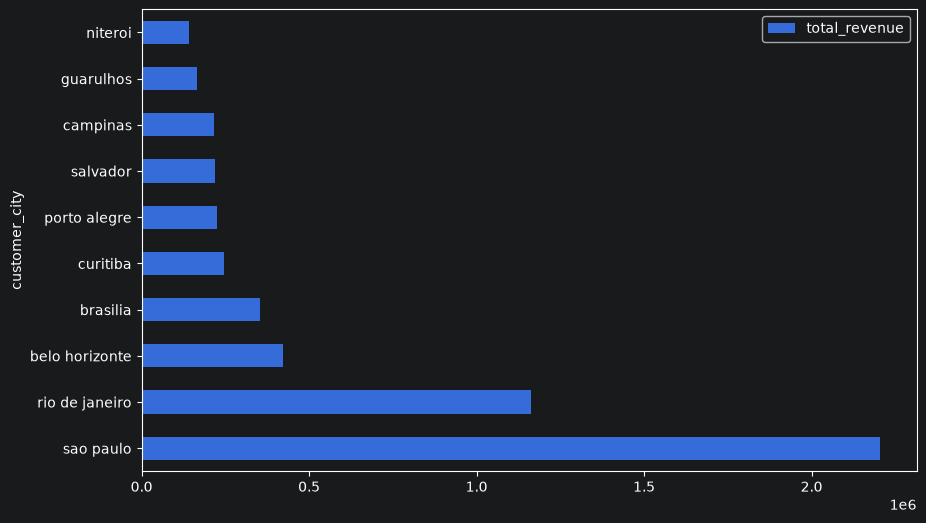

In [27]:
top_cities_revenue["average_order_value"] = (
    top_cities_revenue["total_revenue"] /
    top_cities_revenue["number_of_orders"]

)
print(top_cities_revenue)
top_cities_revenue
top_cities_revenue.head(10).plot(
    x="customer_city",
    y="total_revenue",
    kind="barh",
    figsize=(10,6)
)

#### Findings

- São Paulo generated the highest revenue (**2,203,373.09 BRL**), making it the company's largest and most important market.
- Rio de Janeiro ranked second with **1,161,927.36 BRL**, generating almost half the revenue of São Paulo.
- Belo Horizonte, Brasília and Curitiba completed the top five cities by total revenue.
- Revenue was highly concentrated in a small number of major Brazilian cities, indicating that large urban areas are the company's primary markets.
- The company could prioritize marketing investments and logistics improvements in these high-performing cities while exploring opportunities to expand its presence in smaller markets.


## 6. Customer Lifetime Value Analysis

This section analyzes customer lifetime revenue to identify the most valuable customers and evaluate how revenue is distributed across the customer base.

Understanding customer value helps businesses prioritize retention strategies and allocate marketing resources more effectively.

### 7.1 Total Customer Lifetime Revenue
The total revenue generated by each customer was calculated by summing all payments associated with their completed orders.

This metric represents each customer's lifetime value within the available dataset.

In [30]:
total_lifetime_revenue = (
    orders_customers_payments
    .groupby("customer_unique_id", as_index=False)
    .agg(
        total_revenue=("total_payment", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

total_lifetime_revenue.head()



,customer_unique_id,total_revenue
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08
26456,46450c74a0d8c5ca9395da1daac6c120,9553.02
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31


## Customer Revenue Concentration Findings

A total of 46,765 customers generated 80% of the company's revenue, representing approximately 48.7% of the customer base.

This indicates that revenue is relatively distributed across customers rather than being highly concentrated among a small group of high-value customers.

The company may benefit from broad customer retention strategies instead of focusing only on a small number of premium customers.

### 6.2 Pareto Analysis

A Pareto analysis was performed to evaluate how revenue is distributed across customers.

Customers were ranked from the highest to the lowest lifetime revenue. The cumulative revenue and cumulative revenue percentage were then calculated to determine whether a small proportion of customers generated most of the company's revenue.

This analysis helps identify high-value customers and supports customer segmentation and retention strategies.

In [31]:
total_lifetime_revenue["cumulative_revenue"] = (
    total_lifetime_revenue["total_revenue"]
    .cumsum()
)

total_lifetime_revenue["cumulative_percentage"] = (
    total_lifetime_revenue["cumulative_revenue"]
    / total_lifetime_revenue["total_revenue"].sum()
    * 100
)
total_lifetime_revenue["rank"] = (
    total_lifetime_revenue.index + 1
)
print(total_lifetime_revenue.head(10))

                     customer_unique_id  total_revenue  cumulative_revenue  \
3826   0a0a92112bd4c708ca5fde585afaa872       13664.08            13664.08   
26456  46450c74a0d8c5ca9395da1daac6c120        9553.02            23217.10   
81962  da122df9eeddfedc1dc1f5349a1a690c        7571.63            30788.73   
44447  763c8b1c9c68a0229c42c9fc6f662b93        7274.88            38063.61   
82808  dc4802a71eae9be1dd28f5d788ceb526        6929.31            44992.92   
26205  459bef486812aa25204be022145caa62        6922.21            51915.13   
95806  ff4159b92c40ebe40454e3e6a7c35ed6        6726.66            58641.79   
24121  4007669dec559734d6f53e029e360987        6081.54            64723.33   
35070  5d0a2980b292d049061542014e8960bf        4809.44            69532.77   
89688  eebb5dda148d3893cdaf5b5ca3040ccb        4764.34            74297.11   

       cumulative_percentage   rank  
3826                0.085353   3827  
26456               0.145026  26457  
81962               0.19232

In [32]:
pareto_customers = total_lifetime_revenue[
    total_lifetime_revenue["cumulative_percentage"] <= 80
]

pareto_customers
customer_percentage = (
    len(pareto_customers)
    / len(total_lifetime_revenue)
    * 100
)

print(f"{customer_percentage:.2f}% of customers generate 80% of total revenue.")

48.66% of customers generate 80% of total revenue.


#### Findings

- Revenue is moderately concentrated across the customer base.
- Approximately **48.66% of customers generated 80% of the company's total revenue**.
- This indicates that revenue is more evenly distributed than the classic Pareto principle (80/20), where 20% of customers typically generate 80% of revenue.
- Since a relatively large proportion of customers contribute to overall revenue, customer retention strategies should target a broad customer base rather than focusing exclusively on a small group of high-value customers.
- This suggests that the business is not heavily dependent on a very small group of customers, reducing the risk associated with losing a few high-value customers.

# 7. Customer segment
Customers were segmented into four equally sized groups based on their lifetime revenue using quartiles.

This approach makes it possible to compare customer groups with different spending levels and evaluate their contribution to total revenue.

In [39]:
customer_segments = total_lifetime_revenue.copy()

customer_segments["segment"] = pd.qcut(
    customer_segments["total_revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium-Low Value",
        "Medium-High Value",
        "High Value"
    ]
)

customer_segments["segment"].value_counts()

segment
Medium-Low Value     24037
Low Value            24026
High Value           24021
Medium-High Value    24012
Name: count, dtype: int64

In [40]:
segment_analysis = (
    customer_segments
    .groupby("segment",observed=True, as_index=False)
    .agg(
        customers=("customer_unique_id","count"),
        revenue=("total_revenue","sum")
    )
    .reset_index()
)

segment_analysis

,index,segment,customers,revenue
0,0,Low Value,24026,1048859.55
1,1,Medium-Low Value,24037,2013894.32
2,2,Medium-High Value,24012,3397546.40
3,3,High Value,24021,9548571.85


In [41]:
segment_analysis["revenue_percentage"] = (
    segment_analysis["revenue"] /
    segment_analysis["revenue"].sum()
    * 100
).round(2)


segment_analysis["average_customer_value"] = (
    segment_analysis["revenue"] /
    segment_analysis["customers"]
).round(2)

segment_analysis

,index,segment,customers,revenue,revenue_percentage,average_customer_value
0,0,Low Value,24026,1048859.55,6.55,43.66
1,1,Medium-Low Value,24037,2013894.32,12.58,83.78
2,2,Medium-High Value,24012,3397546.40,21.22,141.49
3,3,High Value,24021,9548571.85,59.65,397.51


#### Findings

- Customers were divided into four equally sized segments based on lifetime revenue.
- Although each segment contains approximately 25% of customers, their contribution to total revenue differs substantially.
- The **High Value** segment generated the largest share of total revenue and had the highest average customer value.
- The **Low Value** segment contributed only a small proportion of revenue despite representing the same number of customers.
- These results suggest that retention and loyalty initiatives should prioritize high-value customers while encouraging lower-value customers to increase their spending over time.

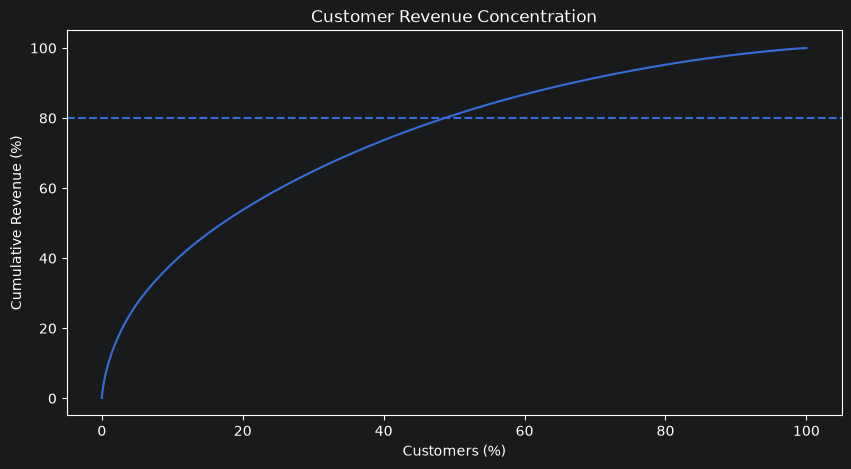

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

customer_percentage = (
    np.arange(len(total_lifetime_revenue))
    /
    len(total_lifetime_revenue)
    * 100
)

plt.plot(
    customer_percentage,
    total_lifetime_revenue["cumulative_percentage"]
)

plt.axhline(
    80,
    linestyle="--"
)

plt.xlabel("Customers (%)")
plt.ylabel("Cumulative Revenue (%)")
plt.title("Customer Revenue Concentration")

plt.show()

## 8.Prepare Data for Tableau
The final analytical dataset was prepared for Tableau to support the development of interactive dashboards.

Only the variables required for business analysis and visualization were included in the exported dataset.

In [34]:
fact_orders = (
    orders_customers_payments [
        [
            "order_id",
            "customer_unique_id",
            "order_status",
            "order_purchase_timestamp",
            "payment_type",
            "payment_installments",
            "total_payment",
            "customer_city",
            "customer_state",
            "order_delivered_customer_date",
            "order_estimated_delivery_date"
        ]
    ].copy()
)
fact_orders.head(10)

,order_id,customer_unique_id,order_status,order_purchase_timestamp,payment_type,payment_installments,total_payment,customer_city,customer_state,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,delivered,2017-10-02 10:56:33,credit_card,1.0,38.71,sao paulo,SP,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,delivered,2018-07-24 20:41:37,boleto,1.0,141.46,barreiras,BA,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,delivered,2018-08-08 08:38:49,credit_card,3.0,179.12,vianopolis,GO,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,delivered,2017-11-18 19:28:06,credit_card,1.0,72.20,sao goncalo do amarante,RN,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,delivered,2018-02-13 21:18:39,credit_card,1.0,28.62,santo andre,SP,2018-02-16 18:17:02,2018-02-26
5,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,delivered,2017-07-09 21:57:05,credit_card,6.0,175.26,congonhinhas,PR,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,invoiced,2017-04-11 12:22:08,credit_card,1.0,65.95,santa rosa,RS,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,delivered,2017-05-16 13:10:30,credit_card,3.0,75.16,nilopolis,RJ,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,delivered,2017-01-23 18:29:09,boleto,1.0,35.95,faxinalzinho,RS,2017-02-02 14:08:10,2017-03-06
9,e69bfb5eb88e0ed6a785585b27e16dbf,299905e3934e9e181bfb2e164dd4b4f8,delivered,2017-07-29 11:55:02,voucher,1.0,169.76,sorocaba,SP,2017-08-16 17:14:30,2017-08-23


### Exported Variables

The exported dataset contains:

- Customer identifier
- Order identifier
- Purchase date
- Order status
- Payment information
- Revenue
- Customer location
- Delivery dates

These fields provide the necessary information to build sales, customer and delivery performance dashboards in Tableau.

In [35]:
fact_orders["delivery_time"] = (
    fact_orders["order_delivered_customer_date"]
    - fact_orders["order_purchase_timestamp"]
).dt.days

fact_orders["delay_days"] = (
    fact_orders["order_delivered_customer_date"]
    - fact_orders["order_estimated_delivery_date"]
).dt.days

fact_orders["order_date"] = fact_orders["order_purchase_timestamp"].dt.date
fact_orders["year"] = fact_orders["order_purchase_timestamp"].dt.year
fact_orders["month"] = fact_orders["order_purchase_timestamp"].dt.month

fact_orders["is_delivered"] = (
    fact_orders["order_delivered_customer_date"].notna()
)

In [36]:
customer_summary = (
    fact_orders
    .groupby("customer_unique_id")
    .agg(
        total_revenue=("total_payment", "sum"),
        total_orders=("order_id", "nunique"),
        average_order_value=("total_payment", "mean"),
        customer_state=("customer_state", "first"),
        customer_city=("customer_city", "first"),
        first_purchase=("order_purchase_timestamp", "min"),
        last_purchase=("order_purchase_timestamp", "max")
    )
    .reset_index()
)
customer_summary.head(10)

,customer_unique_id,total_revenue,total_orders,average_order_value,customer_state,customer_city,first_purchase,last_purchase
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,SP,cajamar,2018-05-10 10:56:27,2018-05-10 10:56:27
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,SP,osasco,2018-05-07 11:11:27,2018-05-07 11:11:27
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,SC,sao jose,2017-03-10 21:05:03,2017-03-10 21:05:03
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,PA,belem,2017-10-12 20:29:41,2017-10-12 20:29:41
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,SP,sorocaba,2017-11-14 19:45:42,2017-11-14 19:45:42
5,0004bd2a26a76fe21f786e4fbd80607f,166.98,1,166.98,SP,sao paulo,2018-04-05 19:33:16,2018-04-05 19:33:16
6,00050ab1314c0e55a6ca13cf7181fecf,35.38,1,35.38,SP,campinas,2018-04-20 12:57:23,2018-04-20 12:57:23
7,00053a61a98854899e70ed204dd4bafe,419.18,1,419.18,PR,curitiba,2018-02-28 11:15:41,2018-02-28 11:15:41
8,0005e1862207bf6ccc02e4228effd9a0,150.12,1,150.12,RJ,teresopolis,2017-03-04 23:32:12,2017-03-04 23:32:12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,129.76,1,129.76,MA,sao luis,2018-03-12 15:22:12,2018-03-12 15:22:12


In [37]:
customer_summary["total_revenue"] = (
    customer_summary["total_revenue"]
    .round(2)
)

customer_summary["average_order_value"] = (
    customer_summary["average_order_value"]
    .round(2)
)

In [42]:
customer_summary = customer_summary.merge(
    customer_segments[
        ["customer_unique_id", "segment"]
    ],
    on="customer_unique_id",
    how="left"
)



customer_summary.head(10)

,customer_unique_id,total_revenue,total_orders,average_order_value,customer_state,customer_city,first_purchase,last_purchase,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,141.90,SP,cajamar,2018-05-10 10:56:27,2018-05-10 10:56:27,Medium-High Value
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,1,27.19,SP,osasco,2018-05-07 11:11:27,2018-05-07 11:11:27,Low Value
2,0000f46a3911fa3c0805444483337064,86.22,1,86.22,SC,sao jose,2017-03-10 21:05:03,2017-03-10 21:05:03,Medium-Low Value
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,43.62,PA,belem,2017-10-12 20:29:41,2017-10-12 20:29:41,Low Value
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,196.89,SP,sorocaba,2017-11-14 19:45:42,2017-11-14 19:45:42,High Value
5,0004bd2a26a76fe21f786e4fbd80607f,166.98,1,166.98,SP,sao paulo,2018-04-05 19:33:16,2018-04-05 19:33:16,Medium-High Value
6,00050ab1314c0e55a6ca13cf7181fecf,35.38,1,35.38,SP,campinas,2018-04-20 12:57:23,2018-04-20 12:57:23,Low Value
7,00053a61a98854899e70ed204dd4bafe,419.18,1,419.18,PR,curitiba,2018-02-28 11:15:41,2018-02-28 11:15:41,High Value
8,0005e1862207bf6ccc02e4228effd9a0,150.12,1,150.12,RJ,teresopolis,2017-03-04 23:32:12,2017-03-04 23:32:12,Medium-High Value
9,0005ef4cd20d2893f0d9fbd94d3c0d97,129.76,1,129.76,MA,sao luis,2018-03-12 15:22:12,2018-03-12 15:22:12,Medium-High Value


In [43]:
customer_summary["customer_type"] = np.where(
    customer_summary["total_orders"] > 1,
    "Repeat Customer",
    "One-time Customer"
)
print(customer_summary["customer_type"].value_counts())

customer_type
One-time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64


In [44]:
customer_summary_type=(
    customer_summary
    .groupby("customer_type")
    .agg(
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        customers = ("customer_unique_id", "count")
    )
    .reset_index()
    )

print(customer_summary_type)





       customer_type  total_revenue  avg_revenue  customers
0  One-time Customer    15064849.41   161.815373      93099
1    Repeat Customer      944022.71   314.989226       2997


In [45]:
customer_summary_type["customer_percentage"] = (
    customer_summary_type["customers"]
    / customer_summary_type["customers"].sum()
    * 100
).round(2)

In [48]:
customer_summary_type["customer_revenue_percentage"] = (
     customer_summary_type["total_revenue"]
     / customer_summary_type["total_revenue"].sum()
     *100
).round(2)
print(customer_summary_type)

       customer_type  total_revenue  avg_revenue  customers  \
0  One-time Customer    15064849.41   161.815373      93099   
1    Repeat Customer      944022.71   314.989226       2997   

   customer_percentage  customer_revenue_percentage  
0                96.88                         94.1  
1                 3.12                          5.9  


Repeat customers represent only 3.12% of the customer base but generate 5.9% of total revenue. Their average revenue per customer is BRL 314.99, compared with BRL 161.82 for one-time customers.

In [40]:
fact_orders.duplicated().sum()

np.int64(0)

In [41]:
customer_summary.duplicated().sum()

np.int64(0)

In [47]:
fact_orders.info()
customer_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_unique_id             99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   payment_type                   99440 non-null  str           
 5   payment_installments           99440 non-null  float64       
 6   total_payment                  99440 non-null  float64       
 7   customer_city                  99441 non-null  str           
 8   customer_state                 99441 non-null  str           
 9   order_delivered_customer_date  96476 non-null  datetime64[us]
 10  order_estimated_delivery_date  99441 non-null  datetime64[us]
 11  delivery_time             

### Duplicate Validation

Potential duplicate records were investigated after creating the analytical table.

The apparent duplicates were caused by removing identifying payment fields during feature selection.

After preserving `payment_sequential`, no exact duplicate records remained, so no rows were removed.

In [107]:
fact_orders.to_csv(
    "fact_orders.csv",
    index=False
)

customer_summary.to_csv(
    "customer_summary.csv",
    index=False
)
customer_summary_type.to_csv(
    "customer_summary_type.csv",
    index=False

)

# 8. Business Recommendations

Based on the findings of this analysis, the following business actions could improve overall performance:

- Prioritize marketing investments in high-performing states and cities, while developing targeted campaigns to increase sales in underperforming regions.
- Maintain a fast, secure and reliable credit card payment experience, as credit cards generate the largest share of total revenue.
- Monitor delivery performance and investigate the causes of delayed deliveries to improve customer satisfaction and operational efficiency.
- Develop customer loyalty programs focused on High Value customers, while encouraging Medium-High Value customers to increase their purchase frequency.
- Continuously monitor monthly sales trends to anticipate seasonal demand, optimize inventory planning and support marketing decisions.

# 9. Conclusion

This project demonstrated a complete end-to-end data analytics workflow using Python and Tableau.

The analysis covered data quality assessment, feature engineering, exploratory data analysis, customer lifetime value, customer segmentation and business recommendations.

The final analytical datasets were exported to Tableau, where interactive dashboards were created to support data-driven business decisions.

# Project Summary

This project analyzed the Olist Brazilian E-commerce dataset using Python and Tableau to identify sales trends, customer behavior and business opportunities.

The project followed a complete end-to-end data analytics workflow, including:

- Data quality assessment and cleaning
- Feature engineering
- Exploratory Data Analysis (EDA)
- Customer Lifetime Value (CLV) analysis
- Pareto analysis
- Customer segmentation
- Business recommendations
- Preparation of analytical datasets for Tableau dashboards

The analysis focused on the following business KPIs:

- Revenue
- Orders
- Customer Lifetime Value
- Average Order Value (AOV)
- Delivery Performance
- Payment Methods
- Geographic Performance
- Customer Segmentation

The final datasets were exported to Tableau to build interactive dashboards for sales and customer analytics, supporting data-driven business decisions.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook
- Tableau Public

In [108]:
customer_summary.groupby("segment_x").agg(
    customers=("customer_unique_id", "count"),
    avg_orders=("total_orders", "mean"),
    avg_revenue=("total_revenue", "mean")
)

,customers,avg_orders,avg_revenue
segment_x,,,
Low Value,24026,1.002372,43.655188
Medium-Low Value,24037,1.013063,83.783098
Medium-High Value,24012,1.032650,141.493686
High Value,24021,1.091170,397.509340
